In [43]:
print("Hello world")

Hello world


In [44]:
import pandas as pd 
test_df = pd.read_csv(r"predictions\test_df.csv")
test_df.label = test_df.label.fillna("None")
test_df.head()

,case_name,sent_text,label,hdr_title,hdr_match,hdr_group,y_labelled
0,ECLI:NL:GHAMS:2015:2960.txt,De kantonrechter heeft in het bestreden vonnis...,None,Feiten,1,Feiten,0
1,ECLI:NL:GHAMS:2015:2960.txt,Deze feiten zijn in hoger beroep niet in gesch...,None,Feiten,1,Feiten,0
2,ECLI:NL:GHAMS:2015:2960.txt,Op [datum] heeft [geïntimeerde] een bedrag van...,materiele feiten,Beoordeling,1,Beoordeling,1
3,ECLI:NL:GHAMS:2015:2960.txt,Op [datum] heeft [appellante] een schriftelijk...,materiele feiten,Beoordeling,1,Beoordeling,1
4,ECLI:NL:GHAMS:2015:2960.txt,Deze verklaring houdt onder meer in: “Dit bedr...,None,Beoordeling,1,Beoordeling,0


In [45]:
# ============================================================
# Run all saved models from registry on an existing dataframe
# and append all prediction/probability outputs to the dataframe
# ============================================================

import os
import re
import json
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification


# ------------------------------------------------------------
# 0. Settings
# ------------------------------------------------------------

df_model_outputs = test_df.copy()

REGISTRY_PATH = "roberta_models\\best_models_registry.json"
TEXT_COL = "sent_text"

BATCH_SIZE = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)
print("Rows:", len(df_model_outputs))


# ------------------------------------------------------------
# 1. Load model registry
# ------------------------------------------------------------

with open(REGISTRY_PATH, "r", encoding="utf-8") as f:
    registry = json.load(f)

print("Models in registry:")
for k in registry.keys():
    print(" -", k)


# ------------------------------------------------------------
# 2. Helper functions
# ------------------------------------------------------------

def clean_col_name(x):
    """
    Make labels safe for dataframe column names.
    Example:
    'materiele feiten' -> 'materiele_feiten'
    'None' -> 'none'
    """
    x = str(x).strip().lower()
    x = re.sub(r"\s+", "_", x)
    x = re.sub(r"[^a-zA-Z0-9_]+", "_", x)
    x = re.sub(r"_+", "_", x).strip("_")
    return x


def resolve_model_path(model_info):
    """
    Prefer saved_path because that should contain the final saved model.
    Fall back to best_model_checkpoint if needed.
    """
    candidates = [
        f"roberta_{model_info.get('saved_path')}"
    ]

    for c in candidates:
        if c is not None and Path(c).exists():
            return c

    raise FileNotFoundError(
        f"Could not find model path for {model_info.get('model_key')}. "
        f"Tried: {candidates}"
    )


def get_labels(model_key, model_info):
    """
    Get labels in the correct order from the registry.
    """
    if "labels_order" in model_info:
        return model_info["labels_order"]

    if "labels" in model_info:
        return model_info["labels"]

    raise ValueError(f"No labels found for model: {model_key}")


def get_tokenizer(model_path, model_info):
    """
    First try loading tokenizer from saved model folder.
    If tokenizer was not saved there, fall back to model_name from registry.
    """
    try:
        return AutoTokenizer.from_pretrained(model_path)
    except Exception:
        fallback_model_name = model_info.get("model_name", "pdelobelle/robbert-v2-dutch-base")
        print(f"Tokenizer not found in {model_path}. Falling back to {fallback_model_name}")
        return AutoTokenizer.from_pretrained(fallback_model_name)


@torch.no_grad()
def predict_with_model(model_key, model_info, texts):
    """
    Run batched inference for one model.
    Returns:
    - pred_idx
    - pred_label
    - probabilities
    - labels
    """
    model_path = resolve_model_path(model_info)
    labels = get_labels(model_key, model_info)

    max_len = model_info.get("max_len", 256)

    print(f"\nRunning model: {model_key}")
    print(f"Path: {model_path}")
    print(f"Labels: {labels}")

    tokenizer = get_tokenizer(model_path, model_info)

    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.to(DEVICE)
    model.eval()

    all_probs = []

    for start in tqdm(range(0, len(texts), BATCH_SIZE), desc=model_key):
        batch_texts = texts[start:start + BATCH_SIZE]

        enc = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        )

        enc = {k: v.to(DEVICE) for k, v in enc.items()}

        outputs = model(**enc)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)

        all_probs.append(probs.detach().cpu().numpy())

    probs = np.vstack(all_probs)
    pred_idx = probs.argmax(axis=1)
    pred_label = np.array([labels[i] for i in pred_idx])

    # Clean up GPU memory after each model
    del model
    del tokenizer
    gc.collect()

    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    return pred_idx, pred_label, probs, labels


def add_multiclass_outputs(df_out, prefix, pred_idx, pred_label, probs, labels):
    """
    Add multiclass prediction columns.
    Example:
    text5_pred_idx
    text5_pred_label
    text5_p_none
    text5_p_beoordeling
    ...
    """
    df_out[f"{prefix}_pred_idx"] = pred_idx
    df_out[f"{prefix}_pred_label"] = pred_label

    for i, lab in enumerate(labels):
        lab_clean = clean_col_name(lab)
        df_out[f"{prefix}_p_{lab_clean}"] = probs[:, i]

    return df_out


def add_stage1_outputs(df_out, pred_idx, pred_label, probs, labels):
    """
    Add Stage 1 gatekeeper outputs using your familiar column names:
    stage1_pred_idx
    stage1_pred_label
    stage1_p0
    stage1_p1
    p_none
    p_labelled
    """
    df_out["stage1_pred_idx"] = pred_idx
    df_out["stage1_pred_label"] = pred_label

    # df_out["stage1_p0"] = probs[:, 0]
    # df_out["stage1_p1"] = probs[:, 1]

    # Convenient aliases
    df_out["p_none"] = probs[:, 0]
    df_out["p_labelled"] = probs[:, 1]

    return df_out


def add_ovr_outputs(df_out, model_key, model_info, pred_idx, pred_label, probs, labels):
    """
    Add OvR outputs.

    For ovr_beoordeling, for example:
    ovr_beoordeling_pred_idx
    ovr_beoordeling_pred_label
    ovr_beoordeling_p0
    ovr_beoordeling_p1
    beoordeling_pred
    beoordeling_p_not
    beoordeling_p_pos
    """
    pos_label = model_info["pos_label"]
    pos_clean = clean_col_name(pos_label)
    prefix = f"ovr_{pos_clean}"

    df_out[f"{prefix}_pred_idx"] = pred_idx
    df_out[f"{prefix}_pred_label"] = pred_label
    df_out[f"{prefix}_p0"] = probs[:, 0]
    df_out[f"{prefix}_p1"] = probs[:, 1]

    # Shorter practical columns
    df_out[f"{pos_clean}_pred"] = pred_idx
    df_out[f"{pos_clean}_pred_label"] = pred_label
    df_out[f"{pos_clean}_p_not"] = probs[:, 0]
    df_out[f"{pos_clean}_p_pos"] = probs[:, 1]

    return df_out


# ------------------------------------------------------------
# 3. Basic checks
# ------------------------------------------------------------

if TEXT_COL not in df_model_outputs.columns:
    raise ValueError(f"Text column '{TEXT_COL}' not found in dataframe.")

df_model_outputs[TEXT_COL] = df_model_outputs[TEXT_COL].fillna("").astype(str)
texts = df_model_outputs[TEXT_COL].tolist()


# ------------------------------------------------------------
# 4. Run all models and append outputs
# ------------------------------------------------------------

for model_key, model_info in registry.items():

    pred_idx, pred_label, probs, labels = predict_with_model(
        model_key=model_key,
        model_info=model_info,
        texts=texts
    )

    if model_key == "stage1_gatekeeper":
        df_model_outputs = add_stage1_outputs(
            df_model_outputs,
            pred_idx,
            pred_label,
            probs,
            labels
        )

    elif model_info.get("type") == "ovr_binary":
        df_model_outputs = add_ovr_outputs(
            df_model_outputs,
            model_key,
            model_info,
            pred_idx,
            pred_label,
            probs,
            labels
        )

    elif model_key == "text_only_5way":
        df_model_outputs = add_multiclass_outputs(
            df_model_outputs,
            prefix="text5",
            pred_idx=pred_idx,
            pred_label=pred_label,
            probs=probs,
            labels=labels
        )

    elif model_key == "stage2_text_only_4way":
        df_model_outputs = add_multiclass_outputs(
            df_model_outputs,
            prefix="stage2",
            pred_idx=pred_idx,
            pred_label=pred_label,
            probs=probs,
            labels=labels
        )

    else:
        # Generic fallback for any future model
        safe_prefix = clean_col_name(model_key)
        df_model_outputs = add_multiclass_outputs(
            df_model_outputs,
            prefix=safe_prefix,
            pred_idx=pred_idx,
            pred_label=pred_label,
            probs=probs,
            labels=labels
        )


# ------------------------------------------------------------
# 5. Optional useful combined columns
# ------------------------------------------------------------

# Stage 2 with Stage 1 gate:
# If Stage 1 says not labelled, final prediction is None.
# Otherwise, use the 4-way Stage 2 prediction.
if "stage1_pred_idx" in df_model_outputs.columns and "stage2_pred_label" in df_model_outputs.columns:
    df_model_outputs["pipeline_stage1_stage2_pred"] = np.where(
        df_model_outputs["stage1_pred_idx"] == 0,
        "None",
        df_model_outputs["stage2_pred_label"]
    )

# OvR winner among the four positive probabilities
ovr_pos_cols = [
    "beoordeling_p_pos",
    "beslissing_p_pos",
    "materiele_feiten_p_pos",
    "proceshandelingen_p_pos"
]

if all(c in df_model_outputs.columns for c in ovr_pos_cols):
    ovr_label_map = {
        "beoordeling_p_pos": "beoordeling",
        "beslissing_p_pos": "beslissing",
        "materiele_feiten_p_pos": "materiele feiten",
        "proceshandelingen_p_pos": "proceshandelingen"
    }

    best_ovr_col = df_model_outputs[ovr_pos_cols].idxmax(axis=1)
    df_model_outputs["ovr_best_label"] = best_ovr_col.map(ovr_label_map)
    df_model_outputs["ovr_best_score"] = df_model_outputs[ovr_pos_cols].max(axis=1)

    # Optional gated OvR prediction
    if "stage1_pred_idx" in df_model_outputs.columns:
        df_model_outputs["pipeline_stage1_ovr_pred"] = np.where(
            df_model_outputs["stage1_pred_idx"] == 0,
            "None",
            df_model_outputs["ovr_best_label"]
        )


# ------------------------------------------------------------
# 6. Save output
# ------------------------------------------------------------

output_path = "predictions/df_all_model_outputs.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

df_model_outputs.to_csv(output_path, index=False, encoding="utf-8-sig")

print("\nDone.")
print("Final shape:", df_model_outputs.shape)
print("Saved to:", output_path)

df_model_outputs.head()

Using device: cuda
Rows: 1502
Models in registry:
 - text_only_5way
 - stage1_gatekeeper
 - stage2_text_only_4way
 - ovr_beoordeling
 - ovr_beslissing
 - ovr_materiele_feiten
 - ovr_proceshandelingen

Running model: text_only_5way
Path: roberta_models\text_only_5way_best_20260203_101227
Labels: ['None', 'beoordeling', 'beslissing', 'materiele feiten', 'proceshandelingen']


text_only_5way:   0%|          | 0/47 [00:00<?, ?it/s]


Running model: stage1_gatekeeper
Path: roberta_models\stage1_gatekeeper_best_20260203_104234
Labels: ['not_labelled', 'labelled']


stage1_gatekeeper:   0%|          | 0/47 [00:00<?, ?it/s]


Running model: stage2_text_only_4way
Path: roberta_models\stage2_text_only_4way_best_20260203_105457
Labels: ['beoordeling', 'beslissing', 'materiele feiten', 'proceshandelingen']


...

ovr_materiele_feiten:   0%|          | 0/47 [00:00<?, ?it/s]


Running model: ovr_proceshandelingen
Path: roberta_models\ovr_proceshandelingen_best_20260203_205755
Labels: ['not_proceshandelingen', 'proceshandelingen']


ovr_proceshandelingen:   0%|          | 0/47 [00:00<?, ?it/s]


Done.
Final shape: (1502, 60)
Saved to: predictions/df_all_model_outputs.csv


,case_name,sent_text,label,hdr_title,hdr_match,hdr_group,y_labelled,text5_pred_idx,text5_pred_label,text5_p_none,...,ovr_proceshandelingen_p0,ovr_proceshandelingen_p1,proceshandelingen_pred,proceshandelingen_pred_label,proceshandelingen_p_not,proceshandelingen_p_pos,pipeline_stage1_stage2_pred,ovr_best_label,ovr_best_score,pipeline_stage1_ovr_pred
0,ECLI:NL:GHAMS:2015:2960.txt,De kantonrechter heeft in het bestreden vonnis...,None,Feiten,1,Feiten,0,1,beoordeling,0.418588,...,0.997785,0.002215,0,not_proceshandelingen,0.997785,0.002215,None,beoordeling,0.990455,None
1,ECLI:NL:GHAMS:2015:2960.txt,Deze feiten zijn in hoger beroep niet in gesch...,None,Feiten,1,Feiten,0,1,beoordeling,0.250456,...,0.997457,0.002543,0,not_proceshandelingen,0.997457,0.002543,beoordeling,beoordeling,0.995667,beoordeling
2,ECLI:NL:GHAMS:2015:2960.txt,Op [datum] heeft [geïntimeerde] een bedrag van...,materiele feiten,Beoordeling,1,Beoordeling,1,3,materiele feiten,0.039820,...,0.993379,0.006621,0,not_proceshandelingen,0.993379,0.006621,materiele feiten,materiele feiten,0.984882,materiele feiten
3,ECLI:NL:GHAMS:2015:2960.txt,Op [datum] heeft [appellante] een schriftelijk...,materiele feiten,Beoordeling,1,Beoordeling,1,3,materiele feiten,0.078092,...,0.995923,0.004077,0,not_proceshandelingen,0.995923,0.004077,materiele feiten,materiele feiten,0.983885,materiele feiten
4,ECLI:NL:GHAMS:2015:2960.txt,Deze verklaring houdt onder meer in: “Dit bedr...,None,Beoordeling,1,Beoordeling,0,0,None,0.984487,...,0.983624,0.016376,0,not_proceshandelingen,0.983624,0.016376,None,materiele feiten,0.323065,None


In [46]:
import os
import re
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

OUTPUT_DIR = "confusion_matrices"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def clean_filename(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", "_", text)
    text = re.sub(r"[^a-zA-Z0-9_]+", "", text)
    return text

def save_cm_png(y_true, y_pred, labels, title, filename=None, display_labels=None, figsize=(7, 6)):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    if display_labels is None:
        display_labels = labels

    if filename is None:
        filename = clean_filename(title) + ".png"

    fig, ax = plt.subplots(figsize=figsize)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=display_labels
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=True
    )

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()

    save_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved confusion matrix to: {save_path}")

## 5 Way Classification

In [47]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

# ------------------------------------------------------------
# 5-way classification evaluation
# ------------------------------------------------------------

LABELS_5WAY = [
    "None",
    "beoordeling",
    "beslissing",
    "materiele feiten",
    "proceshandelingen"
]

y_true = df_model_outputs["label"]
y_pred = df_model_outputs["text5_pred_label"]

# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

acc = accuracy_score(y_true, y_pred)
print("5-way classification accuracy:", round(acc, 4))

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\nClassification Report - 5-way model")
print(
    classification_report(
        y_true,
        y_pred,
        labels=LABELS_5WAY,
        target_names=LABELS_5WAY,
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=LABELS_5WAY
)
print("\nRaw Confusion Matrix (5-way model)")
print(cm)

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{label}" for label in LABELS_5WAY],
    columns=[f"pred_{label}" for label in LABELS_5WAY]
)

print("\nConfusion Matrix - 5-way model")
display(cm_df)

5-way classification accuracy: 0.6658

Classification Report - 5-way model
                   precision    recall  f1-score   support

             None     0.7033    0.7579    0.7295       541
      beoordeling     0.6355    0.6992    0.6659       389
       beslissing     0.8947    0.7391    0.8095        69
 materiele feiten     0.6423    0.5320    0.5820       297
proceshandelingen     0.5798    0.5291    0.5533       206

         accuracy                         0.6658      1502
        macro avg     0.6911    0.6515    0.6680      1502
     weighted avg     0.6655    0.6658    0.6634      1502


Raw Confusion Matrix (5-way model)
[[410  75   4  31  21]
 [ 59 272   2  31  25]
 [ 14   2  51   2   0]
 [ 76  30   0 158  33]
 [ 24  49   0  24 109]]

Confusion Matrix - 5-way model


,pred_None,pred_beoordeling,pred_beslissing,pred_materiele feiten,pred_proceshandelingen
true_None,410,75,4,31,21
true_beoordeling,59,272,2,31,25
true_beslissing,14,2,51,2,0
true_materiele feiten,76,30,0,158,33
true_proceshandelingen,24,49,0,24,109


## OVR Models 

In [48]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

# ------------------------------------------------------------
# OvR evaluation on Stage 2 legal-only subset
# Excludes gold label == "None"
# ------------------------------------------------------------

LEGAL_LABELS = [
    "beoordeling",
    "beslissing",
    "materiele feiten",
    "proceshandelingen"
]

ovr_settings = {
    "beoordeling": "beoordeling_pred",
    "beslissing": "beslissing_pred",
    "materiele feiten": "materiele_feiten_pred",
    "proceshandelingen": "proceshandelingen_pred",
}

# Only evaluate OvR models on sentences that truly belong to one of the 4 legal classes
ovr_eval_df = df_model_outputs[df_model_outputs["label"].isin(LEGAL_LABELS)].copy()

print("Total rows in full dataframe:", len(df_model_outputs))
print("Rows used for OvR Stage 2 evaluation:", len(ovr_eval_df))
print("Excluded None rows:", len(df_model_outputs) - len(ovr_eval_df))


# ------------------------------------------------------------
# Evaluate each OvR model separately
# ------------------------------------------------------------

for target_label, pred_col in ovr_settings.items():
    
    print("\n" + "=" * 80)
    print(f"OvR evaluation for: {target_label}")
    print("=" * 80)
    
    if pred_col not in ovr_eval_df.columns:
        raise ValueError(f"Prediction column not found: {pred_col}")
    
    # Binary gold labels:
    # 1 = current target label
    # 0 = any other legal label
    y_true = (ovr_eval_df["label"] == target_label).astype(int)
    
    # Binary model prediction:
    # 1 = predicted as target label
    # 0 = predicted as not target label
    y_pred = ovr_eval_df[pred_col].astype(int)
    
    acc = accuracy_score(y_true, y_pred)
    print(f"\nAccuracy for {target_label}: {acc:.4f}")
    
    print("\nClassification Report")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=[f"not_{target_label}", target_label],
            digits=4,
            zero_division=0
        )
    )
    
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    
    cm_df = pd.DataFrame(
        cm,
        index=[f"true_not_{target_label}", f"true_{target_label}"],
        columns=[f"pred_not_{target_label}", f"pred_{target_label}"]
    )
    
    print("Confusion Matrix")
    display(cm_df)

Total rows in full dataframe: 1502
Rows used for OvR Stage 2 evaluation: 961
Excluded None rows: 541

OvR evaluation for: beoordeling

Accuracy for beoordeling: 0.8189

Classification Report
                 precision    recall  f1-score   support

not_beoordeling     0.8618    0.8287    0.8449       572
    beoordeling     0.7616    0.8046    0.7825       389

       accuracy                         0.8189       961
      macro avg     0.8117    0.8166    0.8137       961
   weighted avg     0.8212    0.8189    0.8197       961

Confusion Matrix


,pred_not_beoordeling,pred_beoordeling
true_not_beoordeling,474,98
true_beoordeling,76,313



OvR evaluation for: beslissing

Accuracy for beslissing: 0.9906

Classification Report
                precision    recall  f1-score   support

not_beslissing     0.9922    0.9978    0.9950       892
    beslissing     0.9688    0.8986    0.9323        69

      accuracy                         0.9906       961
     macro avg     0.9805    0.9482    0.9637       961
  weighted avg     0.9905    0.9906    0.9905       961

Confusion Matrix


,pred_not_beslissing,pred_beslissing
true_not_beslissing,890,2
true_beslissing,7,62



OvR evaluation for: materiele feiten

Accuracy for materiele feiten: 0.8377

Classification Report
                      precision    recall  f1-score   support

not_materiele feiten     0.8618    0.9111    0.8858       664
    materiele feiten     0.7722    0.6734    0.7194       297

            accuracy                         0.8377       961
           macro avg     0.8170    0.7923    0.8026       961
        weighted avg     0.8341    0.8377    0.8344       961

Confusion Matrix


,pred_not_materiele feiten,pred_materiele feiten
true_not_materiele feiten,605,59
true_materiele feiten,97,200



OvR evaluation for: proceshandelingen

Accuracy for proceshandelingen: 0.8460

Classification Report
                       precision    recall  f1-score   support

not_proceshandelingen     0.8798    0.9311    0.9048       755
    proceshandelingen     0.6790    0.5340    0.5978       206

             accuracy                         0.8460       961
            macro avg     0.7794    0.7326    0.7513       961
         weighted avg     0.8368    0.8460    0.8390       961

Confusion Matrix


,pred_not_proceshandelingen,pred_proceshandelingen
true_not_proceshandelingen,703,52
true_proceshandelingen,96,110


## Stage 1: Binary Gatekeeper

In [49]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

# ------------------------------------------------------------
# Stage 1 gatekeeper evaluation
# Binary: None vs labelled
# ------------------------------------------------------------

STAGE1_LABELS = [0, 1]
STAGE1_NAMES = ["not_labelled / None", "labelled"]

y_true = df_model_outputs["y_labelled"].astype(int)
y_pred = df_model_outputs["stage1_pred_idx"].astype(int)

# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

acc = accuracy_score(y_true, y_pred)
print("Stage 1 gatekeeper accuracy:", round(acc, 4))

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\nClassification Report - Stage 1 gatekeeper")
print(
    classification_report(
        y_true,
        y_pred,
        labels=STAGE1_LABELS,
        target_names=STAGE1_NAMES,
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=STAGE1_LABELS
)

cm_df = pd.DataFrame(
    cm,
    index=["true_not_labelled_None", "true_labelled"],
    columns=["pred_not_labelled_None", "pred_labelled"]
)

print("\nConfusion Matrix - Stage 1 gatekeeper")
display(cm_df)

Stage 1 gatekeeper accuracy: 0.7856

Classification Report - Stage 1 gatekeeper
                     precision    recall  f1-score   support

not_labelled / None     0.7494    0.6081    0.6714       541
           labelled     0.8006    0.8855    0.8409       961

           accuracy                         0.7856      1502
          macro avg     0.7750    0.7468    0.7562      1502
       weighted avg     0.7821    0.7856    0.7799      1502


Confusion Matrix - Stage 1 gatekeeper


,pred_not_labelled_None,pred_labelled
true_not_labelled_None,329,212
true_labelled,110,851


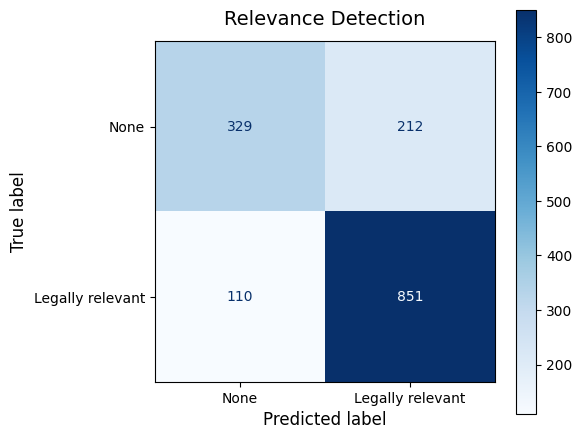

Saved confusion matrix to: confusion_matrices\confusion_matrix_stage1.png


In [50]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# ------------------------------------------------------------
# Save confusion matrix as PNG
# ------------------------------------------------------------

output_dir = "confusion_matrices"
os.makedirs(output_dir, exist_ok=True)

display_labels = [
    "None",
    "Legally relevant"
]

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

ax.set_title("Relevance Detection", fontsize=14, pad=12)
ax.set_xlabel("Predicted label", fontsize=12)
ax.set_ylabel("True label", fontsize=12)

ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

plt.tight_layout()

save_path = os.path.join(output_dir, "confusion_matrix_stage1.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved confusion matrix to: {save_path}")

## Stage 2: 4 way (Without None)

In [51]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

# ------------------------------------------------------------
# Stage 2 4-way evaluation
# Only evaluate on gold labelled / legal-role sentences
# ------------------------------------------------------------

STAGE2_LABELS = [
    "beoordeling",
    "beslissing",
    "materiele feiten",
    "proceshandelingen"
]

# Keep only sentences that truly belong to one of the 4 legal labels
stage2_eval_df = df_model_outputs[
    df_model_outputs["label"].isin(STAGE2_LABELS)
].copy()

print("Total rows in full dataframe:", len(df_model_outputs))
print("Rows used for Stage 2 4-way evaluation:", len(stage2_eval_df))
print("Excluded None rows:", len(df_model_outputs) - len(stage2_eval_df))

# ------------------------------------------------------------
# Gold and predicted labels
# ------------------------------------------------------------

y_true = stage2_eval_df["label"]
y_pred = stage2_eval_df["stage2_pred_label"]

# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

acc = accuracy_score(y_true, y_pred)
print("\nStage 2 4-way accuracy:", round(acc, 4))

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\nClassification Report - Stage 2 4-way model")
print(
    classification_report(
        y_true,
        y_pred,
        labels=STAGE2_LABELS,
        target_names=STAGE2_LABELS,
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=STAGE2_LABELS
)

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{label}" for label in STAGE2_LABELS],
    columns=[f"pred_{label}" for label in STAGE2_LABELS]
)

print("\nConfusion Matrix - Stage 2 4-way model")
display(cm_df)

Total rows in full dataframe: 1502
Rows used for Stage 2 4-way evaluation: 961
Excluded None rows: 541

Stage 2 4-way accuracy: 0.7315

Classification Report - Stage 2 4-way model
                   precision    recall  f1-score   support

      beoordeling     0.7364    0.8329    0.7817       389
       beslissing     0.9677    0.8696    0.9160        69
 materiele feiten     0.7720    0.6498    0.7057       297
proceshandelingen     0.6029    0.6117    0.6072       206

         accuracy                         0.7315       961
        macro avg     0.7697    0.7410    0.7526       961
     weighted avg     0.7354    0.7315    0.7304       961


Confusion Matrix - Stage 2 4-way model


,pred_beoordeling,pred_beslissing,pred_materiele feiten,pred_proceshandelingen
true_beoordeling,324,2,36,27
true_beslissing,7,60,2,0
true_materiele feiten,48,0,193,56
true_proceshandelingen,61,0,19,126


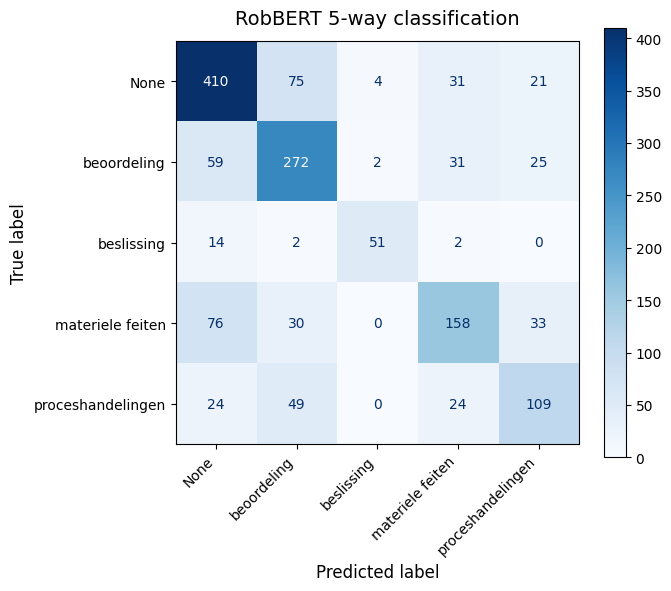

Saved confusion matrix to: confusion_matrices\confusion_matrix_robbert_5way.png


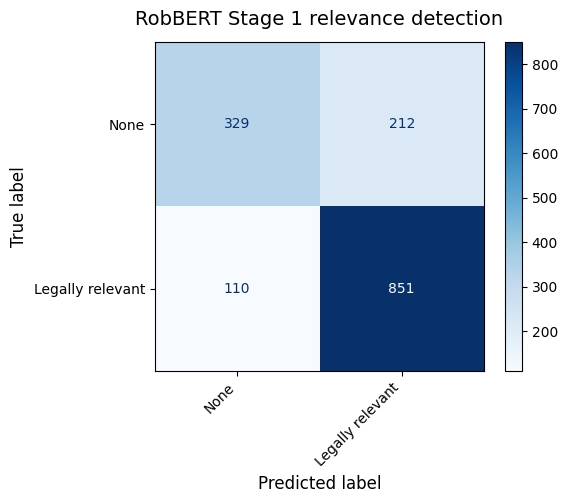

Saved confusion matrix to: confusion_matrices\confusion_matrix_robbert_stage1.png


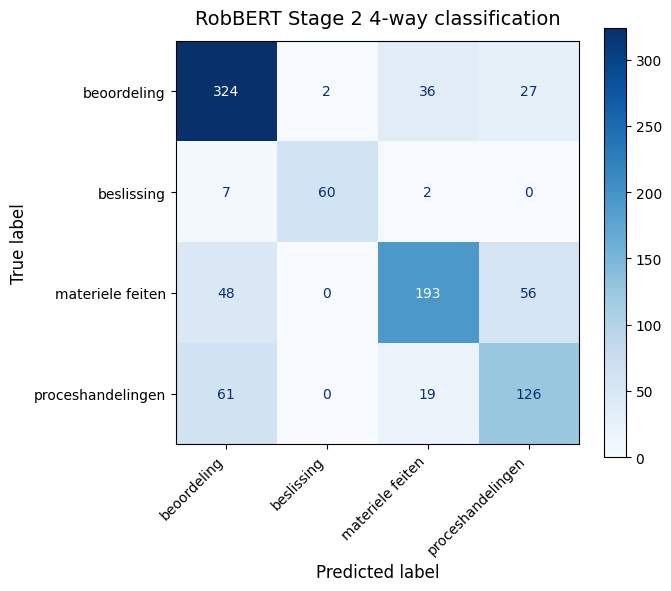

Saved confusion matrix to: confusion_matrices\confusion_matrix_robbert_stage2_4way.png


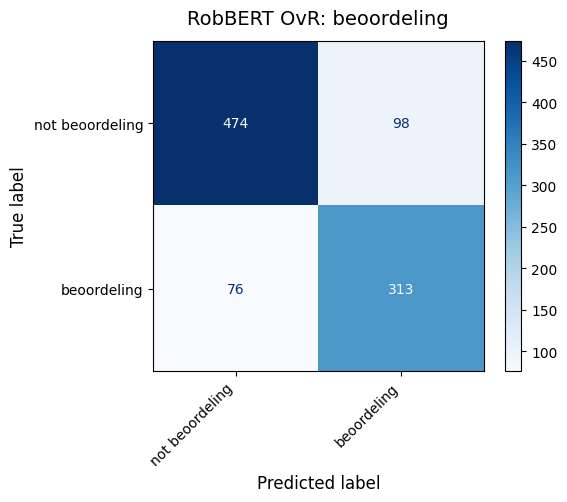

Saved confusion matrix to: confusion_matrices\confusion_matrix_robbert_ovr_beoordeling.png


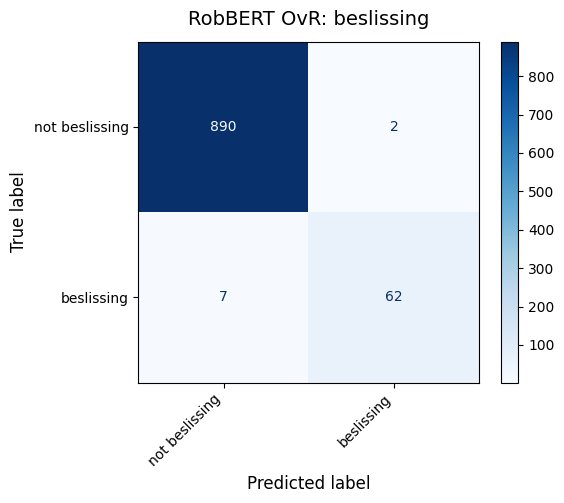

Saved confusion matrix to: confusion_matrices\confusion_matrix_robbert_ovr_beslissing.png


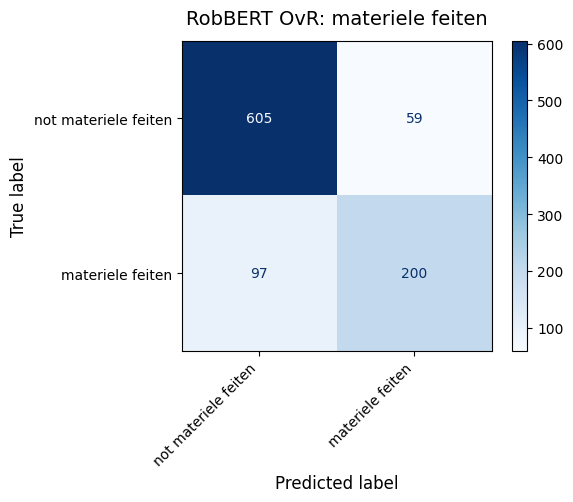

Saved confusion matrix to: confusion_matrices\confusion_matrix_robbert_ovr_materiele_feiten.png


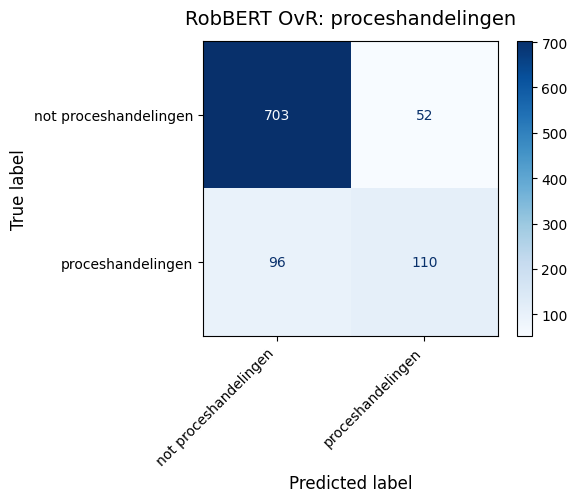

Saved confusion matrix to: confusion_matrices\confusion_matrix_robbert_ovr_proceshandelingen.png


In [52]:
# ------------------------------------------------------------
# Save original model confusion matrices
# ------------------------------------------------------------

save_cm_png(
    y_true=df_model_outputs["label"],
    y_pred=df_model_outputs["text5_pred_label"],
    labels=LABELS_5WAY,
    title="RobBERT 5-way classification",
    filename="confusion_matrix_robbert_5way.png"
)

save_cm_png(
    y_true=df_model_outputs["y_labelled"].astype(int),
    y_pred=df_model_outputs["stage1_pred_idx"].astype(int),
    labels=[0, 1],
    display_labels=["None", "Legally relevant"],
    title="RobBERT Stage 1 relevance detection",
    filename="confusion_matrix_robbert_stage1.png",
    figsize=(6, 5)
)

stage2_eval_df = df_model_outputs[
    df_model_outputs["label"].isin(STAGE2_LABELS)
].copy()

save_cm_png(
    y_true=stage2_eval_df["label"],
    y_pred=stage2_eval_df["stage2_pred_label"],
    labels=STAGE2_LABELS,
    title="RobBERT Stage 2 4-way classification",
    filename="confusion_matrix_robbert_stage2_4way.png"
)

ovr_eval_df = df_model_outputs[
    df_model_outputs["label"].isin(LEGAL_LABELS)
].copy()

ovr_settings = {
    "beoordeling": "beoordeling_pred",
    "beslissing": "beslissing_pred",
    "materiele feiten": "materiele_feiten_pred",
    "proceshandelingen": "proceshandelingen_pred",
}

for target_label, pred_col in ovr_settings.items():

    y_true = (ovr_eval_df["label"] == target_label).astype(int)
    y_pred = ovr_eval_df[pred_col].astype(int)

    save_cm_png(
        y_true=y_true,
        y_pred=y_pred,
        labels=[0, 1],
        display_labels=[f"not {target_label}", target_label],
        title=f"RobBERT OvR: {target_label}",
        filename=f"confusion_matrix_robbert_ovr_{clean_filename(target_label)}.png",
        figsize=(6, 5)
    )

## Bayesian Update

In [53]:
import numpy as np
import pandas as pd
import re
import os

# ------------------------------------------------------------
# 0. Setup
# ------------------------------------------------------------

robbert_bayes_df = df_model_outputs.copy()
train_df = pd.read_csv(r"predictions\train_df.csv")
train_df["label"] = train_df["label"].fillna("None").astype(str).str.strip()
robbert_bayes_df["label"] = robbert_bayes_df["label"].fillna("None").astype(str).str.strip()

LAM = 3.0
ALPHA = 1.0

ALL_LABELS = [
    "None",
    "beoordeling",
    "beslissing",
    "materiele feiten",
    "proceshandelingen"
]

LEGAL_LABELS = [
    "beoordeling",
    "beslissing",
    "materiele feiten",
    "proceshandelingen"
]


# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------

def clean_col_name(x):
    x = str(x).strip().lower()
    x = re.sub(r"\s+", "_", x)
    x = re.sub(r"[^a-zA-Z0-9_]+", "_", x)
    x = re.sub(r"_+", "_", x).strip("_")
    return x


def make_header_prior(df_train, label_col, labels, alpha=1.0):
    """
    Estimate P(label | hdr_group) from training data only.
    """
    counts = (
        df_train
        .groupby(["hdr_group", label_col])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=labels, fill_value=0)
    )

    probs = counts + alpha
    probs = probs.div(probs.sum(axis=1), axis=0)

    return probs


def make_global_prior(df_train, label_col, labels, alpha=1.0):
    """
    Fallback prior for unseen header groups.
    """
    counts = df_train[label_col].value_counts().reindex(labels, fill_value=0) + alpha
    prior = counts / counts.sum()
    return prior.values


def get_meta_prior_df(df_apply, header_prior_train, global_prior, labels):
    """
    Create metadata prior matrix for the dataframe being predicted.
    """
    def get_prior_for_row(hdr_group):
        if pd.notna(hdr_group) and hdr_group in header_prior_train.index:
            return header_prior_train.loc[hdr_group].values
        return global_prior

    meta_prior_mat = np.vstack(
        df_apply["hdr_group"].apply(get_prior_for_row)
    )

    return pd.DataFrame(
        meta_prior_mat,
        columns=labels,
        index=df_apply.index
    )


def combine_log_scores(text_probs_df, meta_prior_df, lam=1.0, eps=1e-12):
    """
    Bayesian-style log fusion:
    log score = log P(label | text) + lambda * log P(label | header)
    """
    text = np.clip(text_probs_df.values, eps, 1.0)
    meta = np.clip(meta_prior_df.values, eps, 1.0)

    log_score = np.log(text) + lam * np.log(meta)

    # numerical stability
    log_score = log_score - log_score.max(axis=1, keepdims=True)

    score = np.exp(log_score)
    score = score / score.sum(axis=1, keepdims=True)

    return pd.DataFrame(
        score,
        columns=text_probs_df.columns,
        index=text_probs_df.index
    )


def add_bayes_prob_columns(df, prefix, bayes_probs, labels):
    """
    Add Bayesian-updated probability columns and prediction label.
    """
    for lab in labels:
        clean_lab = clean_col_name(lab)
        df[f"{prefix}_p_{clean_lab}"] = bayes_probs[lab]

    df[f"{prefix}_pred_label"] = bayes_probs.idxmax(axis=1)

    return df

In [54]:
# ------------------------------------------------------------
# RobBERT 5-way Bayesian update
# ------------------------------------------------------------

robbert_5way_prob_cols = {
    "None": "text5_p_none",
    "beoordeling": "text5_p_beoordeling",
    "beslissing": "text5_p_beslissing",
    "materiele feiten": "text5_p_materiele_feiten",
    "proceshandelingen": "text5_p_proceshandelingen"
}

robbert_5way_text_probs = robbert_bayes_df[
    [robbert_5way_prob_cols[label] for label in ALL_LABELS]
].copy()

robbert_5way_text_probs.columns = ALL_LABELS

header_prior_5way = make_header_prior(
    df_train=train_df,
    label_col="label",
    labels=ALL_LABELS,
    alpha=ALPHA
)

global_prior_5way = make_global_prior(
    df_train=train_df,
    label_col="label",
    labels=ALL_LABELS,
    alpha=ALPHA
)

meta_prior_5way = get_meta_prior_df(
    df_apply=robbert_bayes_df,
    header_prior_train=header_prior_5way,
    global_prior=global_prior_5way,
    labels=ALL_LABELS
)

robbert_bayes_5way_probs = combine_log_scores(
    text_probs_df=robbert_5way_text_probs,
    meta_prior_df=meta_prior_5way,
    lam=LAM
)

robbert_bayes_df = add_bayes_prob_columns(
    df=robbert_bayes_df,
    prefix="robbert_bayes_5way",
    bayes_probs=robbert_bayes_5way_probs,
    labels=ALL_LABELS
)

print("Done: RobBERT 5-way Bayesian update")

robbert_bayes_df[
    ["label", "text5_pred_label", "robbert_bayes_5way_pred_label"]
].head()

Done: RobBERT 5-way Bayesian update


,label,text5_pred_label,robbert_bayes_5way_pred_label
0,None,beoordeling,None
1,None,beoordeling,None
2,materiele feiten,materiele feiten,materiele feiten
3,materiele feiten,materiele feiten,materiele feiten
4,None,None,None


In [55]:
robbert_bayes_df.columns

Index(['case_name', 'sent_text', 'label', 'hdr_title', 'hdr_match',
       'hdr_group', 'y_labelled', 'text5_pred_idx', 'text5_pred_label',
       'text5_p_none', 'text5_p_beoordeling', 'text5_p_beslissing',
       'text5_p_materiele_feiten', 'text5_p_proceshandelingen',
       'stage1_pred_idx', 'stage1_pred_label', 'p_none', 'p_labelled',
       'stage2_pred_idx', 'stage2_pred_label', 'stage2_p_beoordeling',
       'stage2_p_beslissing', 'stage2_p_materiele_feiten',
       'stage2_p_proceshandelingen', 'ovr_beoordeling_pred_idx',
       'ovr_beoordeling_pred_label', 'ovr_beoordeling_p0',
       'ovr_beoordeling_p1', 'beoordeling_pred', 'beoordeling_pred_label',
       'beoordeling_p_not', 'beoordeling_p_pos', 'ovr_beslissing_pred_idx',
       'ovr_beslissing_pred_label', 'ovr_beslissing_p0', 'ovr_beslissing_p1',
       'beslissing_pred', 'beslissing_pred_label', 'beslissing_p_not',
       'beslissing_p_pos', 'ovr_materiele_feiten_pred_idx',
       'ovr_materiele_feiten_pred_label', '

In [56]:
# ------------------------------------------------------------
# RobBERT Stage 1 Bayesian update
# Binary: 0 = None / not labelled, 1 = labelled
# ------------------------------------------------------------

stage1_train = train_df.copy()

stage1_train["y_stage1"] = np.where(
    stage1_train["label"] == "None",
    0,
    1
)

STAGE1_LABELS = [0, 1]

robbert_stage1_text_probs = robbert_bayes_df[
    ["p_none", "p_labelled"]
].copy()

robbert_stage1_text_probs.columns = STAGE1_LABELS

header_prior_stage1 = make_header_prior(
    df_train=stage1_train,
    label_col="y_stage1",
    labels=STAGE1_LABELS,
    alpha=ALPHA
)

global_prior_stage1 = make_global_prior(
    df_train=stage1_train,
    label_col="y_stage1",
    labels=STAGE1_LABELS,
    alpha=ALPHA
)

meta_prior_stage1 = get_meta_prior_df(
    df_apply=robbert_bayes_df,
    header_prior_train=header_prior_stage1,
    global_prior=global_prior_stage1,
    labels=STAGE1_LABELS
)

robbert_bayes_stage1_probs = combine_log_scores(
    text_probs_df=robbert_stage1_text_probs,
    meta_prior_df=meta_prior_stage1,
    lam=LAM
)

robbert_bayes_df["robbert_bayes_stage1_p0"] = robbert_bayes_stage1_probs[0]
robbert_bayes_df["robbert_bayes_stage1_p1"] = robbert_bayes_stage1_probs[1]

robbert_bayes_df["robbert_bayes_stage1_pred_idx"] = robbert_bayes_stage1_probs.idxmax(axis=1)

robbert_bayes_df["robbert_bayes_stage1_pred_label"] = np.where(
    robbert_bayes_df["robbert_bayes_stage1_pred_idx"] == 0,
    "not_labelled",
    "labelled"
)

print("Done: RobBERT Stage 1 Bayesian update")

robbert_bayes_df[
    ["y_labelled", "stage1_pred_idx", "robbert_bayes_stage1_pred_idx", "p_labelled", "robbert_bayes_stage1_p1"]
].head()

Done: RobBERT Stage 1 Bayesian update


,y_labelled,stage1_pred_idx,robbert_bayes_stage1_pred_idx,p_labelled,robbert_bayes_stage1_p1
0,0,0,0,0.334000,0.182206
1,0,1,1,0.804082,0.645813
2,1,1,1,0.971294,0.997973
3,1,1,1,0.966222,0.997603
4,0,0,0,0.053571,0.451624


In [57]:
# ------------------------------------------------------------
# RobBERT Stage 2 4-way Bayesian update
# ------------------------------------------------------------

stage2_train = train_df[
    train_df["label"].isin(LEGAL_LABELS)
].copy()

robbert_stage2_prob_cols = {
    "beoordeling": "stage2_p_beoordeling",
    "beslissing": "stage2_p_beslissing",
    "materiele feiten": "stage2_p_materiele_feiten",
    "proceshandelingen": "stage2_p_proceshandelingen"
}

robbert_stage2_text_probs = robbert_bayes_df[
    [robbert_stage2_prob_cols[label] for label in LEGAL_LABELS]
].copy()

robbert_stage2_text_probs.columns = LEGAL_LABELS

header_prior_stage2 = make_header_prior(
    df_train=stage2_train,
    label_col="label",
    labels=LEGAL_LABELS,
    alpha=ALPHA
)

global_prior_stage2 = make_global_prior(
    df_train=stage2_train,
    label_col="label",
    labels=LEGAL_LABELS,
    alpha=ALPHA
)

meta_prior_stage2 = get_meta_prior_df(
    df_apply=robbert_bayes_df,
    header_prior_train=header_prior_stage2,
    global_prior=global_prior_stage2,
    labels=LEGAL_LABELS
)

robbert_bayes_stage2_probs = combine_log_scores(
    text_probs_df=robbert_stage2_text_probs,
    meta_prior_df=meta_prior_stage2,
    lam=LAM
)

robbert_bayes_df = add_bayes_prob_columns(
    df=robbert_bayes_df,
    prefix="robbert_bayes_stage2",
    bayes_probs=robbert_bayes_stage2_probs,
    labels=LEGAL_LABELS
)

print("Done: RobBERT Stage 2 Bayesian update")

robbert_bayes_df[
    ["label", "stage2_pred_label", "robbert_bayes_stage2_pred_label"]
].head()

Done: RobBERT Stage 2 Bayesian update


,label,stage2_pred_label,robbert_bayes_stage2_pred_label
0,None,beoordeling,materiele feiten
1,None,beoordeling,materiele feiten
2,materiele feiten,materiele feiten,materiele feiten
3,materiele feiten,materiele feiten,materiele feiten
4,None,proceshandelingen,beoordeling


In [58]:
# ------------------------------------------------------------
# RobBERT OvR Bayesian update
# ------------------------------------------------------------

ovr_train_base = train_df[
    train_df["label"].isin(LEGAL_LABELS)
].copy()

for target_label in LEGAL_LABELS:

    clean_label = clean_col_name(target_label)

    print(f"Running RobBERT OvR Bayesian update for: {target_label}")

    ovr_train = ovr_train_base.copy()

    ovr_train[f"y_{clean_label}"] = np.where(
        ovr_train["label"] == target_label,
        1,
        0
    )

    binary_labels = [0, 1]

    text_probs = robbert_bayes_df[
        [f"{clean_label}_p_not", f"{clean_label}_p_pos"]
    ].copy()

    text_probs.columns = binary_labels

    header_prior_ovr = make_header_prior(
        df_train=ovr_train,
        label_col=f"y_{clean_label}",
        labels=binary_labels,
        alpha=ALPHA
    )

    global_prior_ovr = make_global_prior(
        df_train=ovr_train,
        label_col=f"y_{clean_label}",
        labels=binary_labels,
        alpha=ALPHA
    )

    meta_prior_ovr = get_meta_prior_df(
        df_apply=robbert_bayes_df,
        header_prior_train=header_prior_ovr,
        global_prior=global_prior_ovr,
        labels=binary_labels
    )

    bayes_probs = combine_log_scores(
        text_probs_df=text_probs,
        meta_prior_df=meta_prior_ovr,
        lam=LAM
    )

    robbert_bayes_df[f"robbert_bayes_{clean_label}_p_not"] = bayes_probs[0]
    robbert_bayes_df[f"robbert_bayes_{clean_label}_p_pos"] = bayes_probs[1]
    robbert_bayes_df[f"robbert_bayes_{clean_label}_pred"] = bayes_probs.idxmax(axis=1)

print("Done: RobBERT OvR Bayesian update")

Running RobBERT OvR Bayesian update for: beoordeling
Running RobBERT OvR Bayesian update for: beslissing
Running RobBERT OvR Bayesian update for: materiele feiten
Running RobBERT OvR Bayesian update for: proceshandelingen
Done: RobBERT OvR Bayesian update


In [59]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

def evaluate_model(df, y_true_col, y_pred_col, labels, title):
    """
    Print accuracy, classification report, and confusion matrix.
    """

    y_true = df[y_true_col]
    y_pred = df[y_pred_col]

    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)

    acc = accuracy_score(y_true, y_pred)
    print(f"\nAccuracy: {acc:.4f}")

    print("\nClassification Report")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=labels,
            target_names=[str(x) for x in labels],
            digits=4,
            zero_division=0
        )
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{label}" for label in labels],
        columns=[f"pred_{label}" for label in labels]
    )

    print("\nConfusion Matrix")
    display(cm_df)

In [60]:
# ------------------------------------------------------------
# 1. RobBERT + Bayes 5-way classification
# ------------------------------------------------------------

evaluate_model(
    df=robbert_bayes_df,
    y_true_col="label",
    y_pred_col="robbert_bayes_5way_pred_label",
    labels=ALL_LABELS,
    title="RobBERT + Bayes: 5-way classification"
)


RobBERT + Bayes: 5-way classification

Accuracy: 0.6438

Classification Report
                   precision    recall  f1-score   support

             None     0.5826    0.8152    0.6795       541
      beoordeling     0.6564    0.7121    0.6831       389
       beslissing     0.8710    0.3913    0.5400        69
 materiele feiten     0.7609    0.3535    0.4828       297
proceshandelingen     0.7597    0.5680    0.6500       206

         accuracy                         0.6438      1502
        macro avg     0.7261    0.5680    0.6071      1502
     weighted avg     0.6745    0.6438    0.6311      1502


Confusion Matrix


,pred_None,pred_beoordeling,pred_beslissing,pred_materiele feiten,pred_proceshandelingen
true_None,441,65,3,16,16
true_beoordeling,86,277,1,9,16
true_beslissing,40,0,27,0,2
true_materiele feiten,154,35,0,105,3
true_proceshandelingen,36,45,0,8,117


In [61]:
# ------------------------------------------------------------
# 2. RobBERT + Bayes Stage 1 gatekeeper
# Binary: 0 = None / not labelled, 1 = labelled
# ------------------------------------------------------------

evaluate_model(
    df=robbert_bayes_df,
    y_true_col="y_labelled",
    y_pred_col="robbert_bayes_stage1_pred_idx",
    labels=[0, 1],
    title="RobBERT + Bayes: Stage 1 gatekeeper"
)


RobBERT + Bayes: Stage 1 gatekeeper

Accuracy: 0.7523

Classification Report
              precision    recall  f1-score   support

           0     0.7752    0.4399    0.5613       541
           1     0.7464    0.9282    0.8275       961

    accuracy                         0.7523      1502
   macro avg     0.7608    0.6841    0.6944      1502
weighted avg     0.7568    0.7523    0.7316      1502


Confusion Matrix


,pred_0,pred_1
true_0,238,303
true_1,69,892


In [62]:
# ------------------------------------------------------------
# 3. RobBERT + Bayes Stage 2 4-way classification
# Evaluate only on gold legal-labelled sentences
# ------------------------------------------------------------

stage2_eval_df = robbert_bayes_df[
    robbert_bayes_df["label"].isin(LEGAL_LABELS)
].copy()

print("Total rows:", len(robbert_bayes_df))
print("Rows used for Stage 2 evaluation:", len(stage2_eval_df))
print("Excluded None rows:", len(robbert_bayes_df) - len(stage2_eval_df))

evaluate_model(
    df=stage2_eval_df,
    y_true_col="label",
    y_pred_col="robbert_bayes_stage2_pred_label",
    labels=LEGAL_LABELS,
    title="RobBERT + Bayes: Stage 2 4-way classification"
)

Total rows: 1502
Rows used for Stage 2 evaluation: 961
Excluded None rows: 541

RobBERT + Bayes: Stage 2 4-way classification

Accuracy: 0.7929

Classification Report
                   precision    recall  f1-score   support

      beoordeling     0.7322    0.8715    0.7958       389
       beslissing     0.9828    0.8261    0.8976        69
 materiele feiten     0.8529    0.7811    0.8155       297
proceshandelingen     0.7976    0.6505    0.7166       206

         accuracy                         0.7929       961
        macro avg     0.8414    0.7823    0.8064       961
     weighted avg     0.8015    0.7929    0.7922       961


Confusion Matrix


,pred_beoordeling,pred_beslissing,pred_materiele feiten,pred_proceshandelingen
true_beoordeling,339,1,32,17
true_beslissing,7,57,2,3
true_materiele feiten,51,0,232,14
true_proceshandelingen,66,0,6,134


In [63]:
# ------------------------------------------------------------
# 4. RobBERT + Bayes OvR evaluation
# Each binary OvR model evaluated on gold legal-labelled subset
# ------------------------------------------------------------

ovr_eval_df = robbert_bayes_df[
    robbert_bayes_df["label"].isin(LEGAL_LABELS)
].copy()

print("Total rows:", len(robbert_bayes_df))
print("Rows used for OvR evaluation:", len(ovr_eval_df))
print("Excluded None rows:", len(robbert_bayes_df) - len(ovr_eval_df))

ovr_settings = {
    "beoordeling": "robbert_bayes_beoordeling_pred",
    "beslissing": "robbert_bayes_beslissing_pred",
    "materiele feiten": "robbert_bayes_materiele_feiten_pred",
    "proceshandelingen": "robbert_bayes_proceshandelingen_pred"
}

for target_label, pred_col in ovr_settings.items():

    temp_df = ovr_eval_df.copy()

    temp_df[f"gold_{clean_col_name(target_label)}"] = (
        temp_df["label"] == target_label
    ).astype(int)

    evaluate_model(
        df=temp_df,
        y_true_col=f"gold_{clean_col_name(target_label)}",
        y_pred_col=pred_col,
        labels=[0, 1],
        title=f"RobBERT + Bayes: OvR binary model for {target_label}"
    )

Total rows: 1502
Rows used for OvR evaluation: 961
Excluded None rows: 541

RobBERT + Bayes: OvR binary model for beoordeling

Accuracy: 0.8522

Classification Report
              precision    recall  f1-score   support

           0     0.8583    0.9003    0.8788       572
           1     0.8421    0.7815    0.8107       389

    accuracy                         0.8522       961
   macro avg     0.8502    0.8409    0.8448       961
weighted avg     0.8518    0.8522    0.8512       961


Confusion Matrix


,pred_0,pred_1
true_0,515,57
true_1,85,304



RobBERT + Bayes: OvR binary model for beslissing

Accuracy: 0.9875

Classification Report
              precision    recall  f1-score   support

           0     0.9878    0.9989    0.9933       892
           1     0.9831    0.8406    0.9062        69

    accuracy                         0.9875       961
   macro avg     0.9854    0.9197    0.9498       961
weighted avg     0.9875    0.9875    0.9871       961


Confusion Matrix


,pred_0,pred_1
true_0,891,1
true_1,11,58



RobBERT + Bayes: OvR binary model for materiele feiten

Accuracy: 0.8377

Classification Report
              precision    recall  f1-score   support

           0     0.8136    0.9925    0.8942       664
           1     0.9669    0.4916    0.6518       297

    accuracy                         0.8377       961
   macro avg     0.8902    0.7420    0.7730       961
weighted avg     0.8610    0.8377    0.8193       961


Confusion Matrix


,pred_0,pred_1
true_0,659,5
true_1,151,146



RobBERT + Bayes: OvR binary model for proceshandelingen

Accuracy: 0.8751

Classification Report
              precision    recall  f1-score   support

           0     0.8731    0.9841    0.9253       755
           1     0.8909    0.4757    0.6203       206

    accuracy                         0.8751       961
   macro avg     0.8820    0.7299    0.7728       961
weighted avg     0.8769    0.8751    0.8599       961


Confusion Matrix


,pred_0,pred_1
true_0,743,12
true_1,108,98


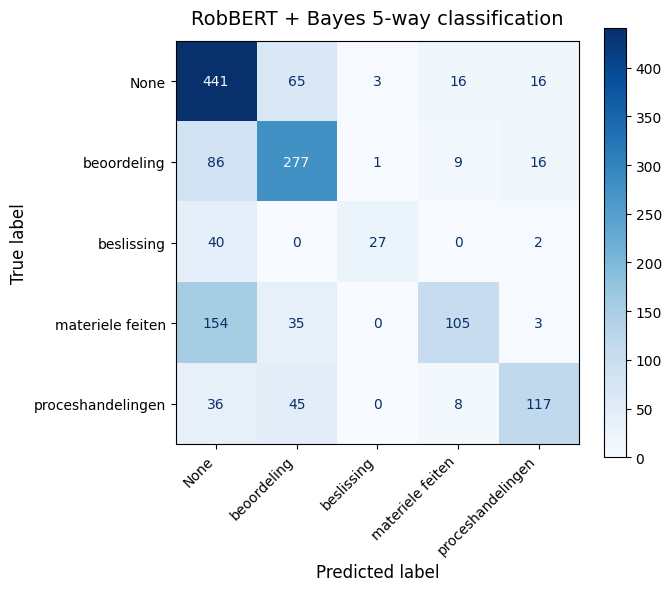

Saved confusion matrix to: confusion_matrices\confusion_matrix_robbert_bayes_5way.png


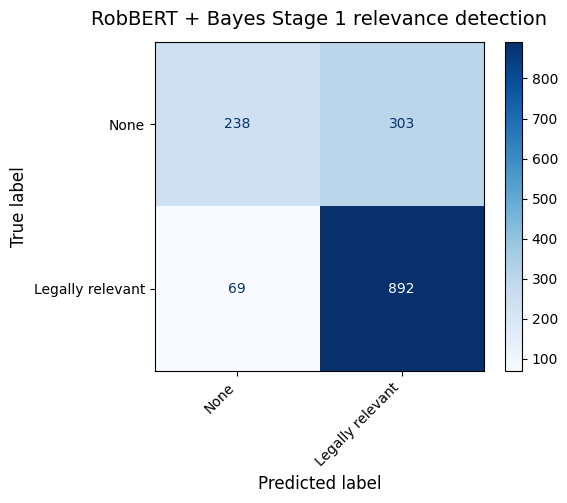

Saved confusion matrix to: confusion_matrices\confusion_matrix_robbert_bayes_stage1.png


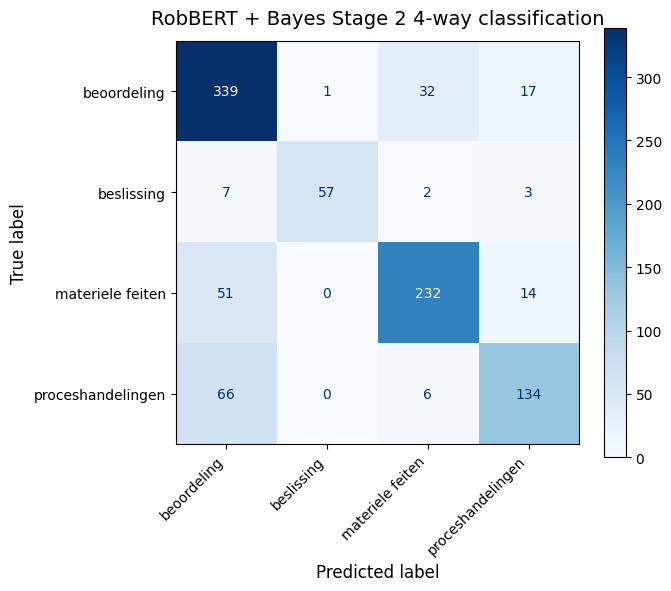

Saved confusion matrix to: confusion_matrices\confusion_matrix_robbert_bayes_stage2_4way.png


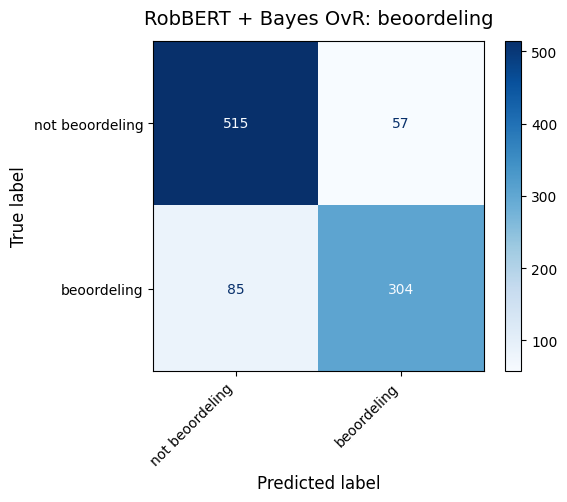

Saved confusion matrix to: confusion_matrices\confusion_matrix_robbert_bayes_ovr_beoordeling.png


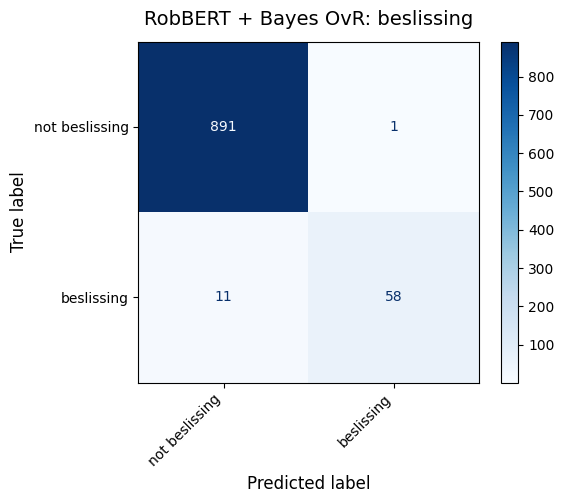

Saved confusion matrix to: confusion_matrices\confusion_matrix_robbert_bayes_ovr_beslissing.png


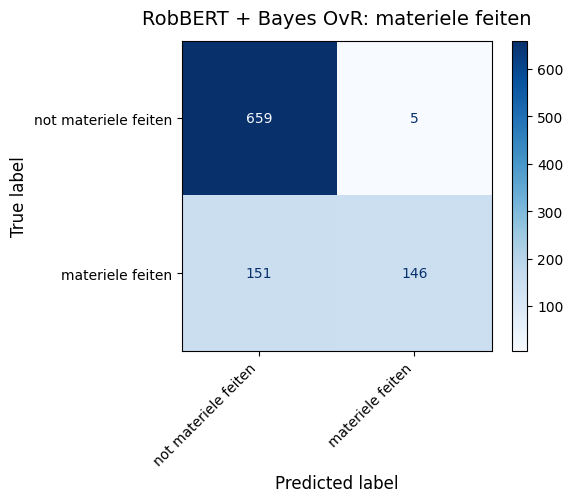

Saved confusion matrix to: confusion_matrices\confusion_matrix_robbert_bayes_ovr_materiele_feiten.png


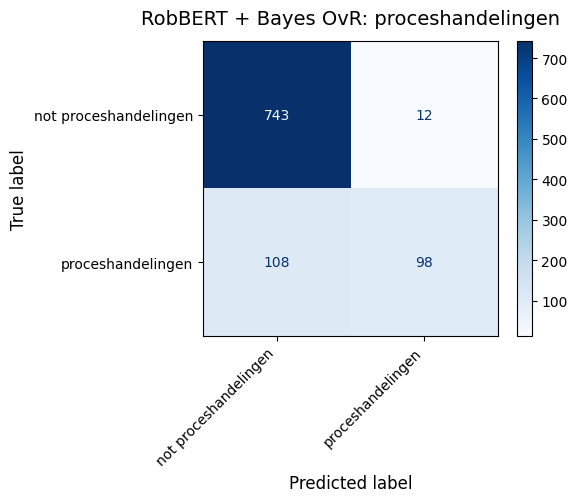

Saved confusion matrix to: confusion_matrices\confusion_matrix_robbert_bayes_ovr_proceshandelingen.png


In [64]:
# ------------------------------------------------------------
# Save RobBERT + Bayes confusion matrices
# ------------------------------------------------------------

save_cm_png(
    y_true=robbert_bayes_df["label"],
    y_pred=robbert_bayes_df["robbert_bayes_5way_pred_label"],
    labels=ALL_LABELS,
    title="RobBERT + Bayes 5-way classification",
    filename="confusion_matrix_robbert_bayes_5way.png"
)

save_cm_png(
    y_true=robbert_bayes_df["y_labelled"].astype(int),
    y_pred=robbert_bayes_df["robbert_bayes_stage1_pred_idx"].astype(int),
    labels=[0, 1],
    display_labels=["None", "Legally relevant"],
    title="RobBERT + Bayes Stage 1 relevance detection",
    filename="confusion_matrix_robbert_bayes_stage1.png",
    figsize=(6, 5)
)

stage2_bayes_eval_df = robbert_bayes_df[
    robbert_bayes_df["label"].isin(LEGAL_LABELS)
].copy()

save_cm_png(
    y_true=stage2_bayes_eval_df["label"],
    y_pred=stage2_bayes_eval_df["robbert_bayes_stage2_pred_label"],
    labels=LEGAL_LABELS,
    title="RobBERT + Bayes Stage 2 4-way classification",
    filename="confusion_matrix_robbert_bayes_stage2_4way.png"
)

ovr_bayes_eval_df = robbert_bayes_df[
    robbert_bayes_df["label"].isin(LEGAL_LABELS)
].copy()

ovr_bayes_settings = {
    "beoordeling": "robbert_bayes_beoordeling_pred",
    "beslissing": "robbert_bayes_beslissing_pred",
    "materiele feiten": "robbert_bayes_materiele_feiten_pred",
    "proceshandelingen": "robbert_bayes_proceshandelingen_pred",
}

for target_label, pred_col in ovr_bayes_settings.items():

    y_true = (ovr_bayes_eval_df["label"] == target_label).astype(int)
    y_pred = ovr_bayes_eval_df[pred_col].astype(int)

    save_cm_png(
        y_true=y_true,
        y_pred=y_pred,
        labels=[0, 1],
        display_labels=[f"not {target_label}", target_label],
        title=f"RobBERT + Bayes OvR: {target_label}",
        filename=f"confusion_matrix_robbert_bayes_ovr_{clean_filename(target_label)}.png",
        figsize=(6, 5)
    )

Pipeline Evaluations

In [65]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

ALL_LABELS = [
    "None",
    "beoordeling",
    "beslissing",
    "materiele feiten",
    "proceshandelingen"
]

LEGAL_LABELS = [
    "beoordeling",
    "beslissing",
    "materiele feiten",
    "proceshandelingen"
]


def make_pipeline_A_probabilistic(
    df,
    stage1_p_none_col,
    stage1_p_labelled_col,
    stage2_prob_cols,
    prefix
):
    """
    Pipeline A probabilistic combination.

    Final 5-way probabilities:
        P(None) = P(Stage 1 = None)
        P(legal label) = P(Stage 1 = labelled) * P(Stage 2 = legal label | labelled)
    """

    df = df.copy()

    p_none = df[stage1_p_none_col].astype(float).values
    p_labelled = df[stage1_p_labelled_col].astype(float).values

    df[f"{prefix}_p_none"] = p_none

    for label in LEGAL_LABELS:
        clean_label = label.replace(" ", "_")
        df[f"{prefix}_p_{clean_label}"] = (
            p_labelled * df[stage2_prob_cols[label]].astype(float).values
        )

    final_prob_cols = [
        f"{prefix}_p_none",
        f"{prefix}_p_beoordeling",
        f"{prefix}_p_beslissing",
        f"{prefix}_p_materiele_feiten",
        f"{prefix}_p_proceshandelingen"
    ]

    probs_for_pred = df[final_prob_cols].copy()
    probs_for_pred.columns = ALL_LABELS

    df[f"{prefix}_pred"] = probs_for_pred.idxmax(axis=1)

    return df


def evaluate_5way_prediction(df, pred_col, title):
    y_true = df["label"].fillna("None").astype(str).str.strip()
    y_pred = df[pred_col].fillna("None").astype(str).str.strip()

    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)

    acc = accuracy_score(y_true, y_pred)
    print(f"\nAccuracy: {acc:.4f}")

    print("\nClassification Report")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=ALL_LABELS,
            target_names=ALL_LABELS,
            digits=4,
            zero_division=0
        )
    )

    cm = confusion_matrix(y_true, y_pred, labels=ALL_LABELS)

    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{label}" for label in ALL_LABELS],
        columns=[f"pred_{label}" for label in ALL_LABELS]
    )

    print("\nConfusion Matrix")
    display(cm_df)

In [66]:
robbert_stage2_prob_cols = {
    "beoordeling": "stage2_p_beoordeling",
    "beslissing": "stage2_p_beslissing",
    "materiele feiten": "stage2_p_materiele_feiten",
    "proceshandelingen": "stage2_p_proceshandelingen"
}

df_model_outputs = make_pipeline_A_probabilistic(
    df=df_model_outputs,
    stage1_p_none_col="p_none",
    stage1_p_labelled_col="p_labelled",
    stage2_prob_cols=robbert_stage2_prob_cols,
    prefix="robbert_pipeline_A_prob"
)

evaluate_5way_prediction(
    df=df_model_outputs,
    pred_col="robbert_pipeline_A_prob_pred",
    title="RobBERT Pipeline A: Probabilistic Stage 1 + Stage 2"
)


RobBERT Pipeline A: Probabilistic Stage 1 + Stage 2

Accuracy: 0.6372

Classification Report
                   precision    recall  f1-score   support

             None     0.7403    0.6322    0.6820       541
      beoordeling     0.5706    0.7378    0.6435       389
       beslissing     0.8438    0.7826    0.8120        69
 materiele feiten     0.6331    0.5286    0.5761       297
proceshandelingen     0.5200    0.5680    0.5429       206

         accuracy                         0.6372      1502
        macro avg     0.6615    0.6498    0.6513      1502
     weighted avg     0.6497    0.6372    0.6380      1502


Confusion Matrix


,pred_None,pred_beoordeling,pred_beslissing,pred_materiele feiten,pred_proceshandelingen
true_None,342,108,8,40,43
true_beoordeling,44,287,2,32,24
true_beslissing,6,7,54,2,0
true_materiele feiten,57,42,0,157,41
true_proceshandelingen,13,59,0,17,117


In [67]:
robbert_bayes_stage2_prob_cols = {
    "beoordeling": "robbert_bayes_stage2_p_beoordeling",
    "beslissing": "robbert_bayes_stage2_p_beslissing",
    "materiele feiten": "robbert_bayes_stage2_p_materiele_feiten",
    "proceshandelingen": "robbert_bayes_stage2_p_proceshandelingen"
}

robbert_bayes_df = make_pipeline_A_probabilistic(
    df=robbert_bayes_df,
    stage1_p_none_col="robbert_bayes_stage1_p0",
    stage1_p_labelled_col="robbert_bayes_stage1_p1",
    stage2_prob_cols=robbert_bayes_stage2_prob_cols,
    prefix="robbert_bayes_pipeline_A_prob"
)

evaluate_5way_prediction(
    df=robbert_bayes_df,
    pred_col="robbert_bayes_pipeline_A_prob_pred",
    title="RobBERT + Bayes Pipeline A: Probabilistic Stage 1 + Stage 2"
)


RobBERT + Bayes Pipeline A: Probabilistic Stage 1 + Stage 2

Accuracy: 0.6252

Classification Report
                   precision    recall  f1-score   support

             None     0.7729    0.4529    0.5711       541
      beoordeling     0.5181    0.8483    0.6433       389
       beslissing     0.8281    0.7681    0.7970        69
 materiele feiten     0.6794    0.5993    0.6369       297
proceshandelingen     0.5991    0.6456    0.6215       206

         accuracy                         0.6252      1502
        macro avg     0.6795    0.6629    0.6539      1502
     weighted avg     0.6671    0.6252    0.6201      1502


Confusion Matrix


,pred_None,pred_beoordeling,pred_beslissing,pred_materiele feiten,pred_proceshandelingen
true_None,245,183,10,47,56
true_beoordeling,12,330,1,29,17
true_beslissing,4,7,53,2,3
true_materiele feiten,55,51,0,178,13
true_proceshandelingen,1,66,0,6,133


## Pipeline B

In [68]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

ALL_LABELS = [
    "None",
    "beoordeling",
    "beslissing",
    "materiele feiten",
    "proceshandelingen"
]

LEGAL_LABELS = [
    "beoordeling",
    "beslissing",
    "materiele feiten",
    "proceshandelingen"
]


def make_pipeline_B_probabilistic(
    df,
    stage1_p_none_col,
    stage1_p_labelled_col,
    ovr_pos_cols,
    legal_labels,
    prefix,
    eps=1e-12
):
    """
    Pipeline B probabilistic combination.

    Step 1:
        Use Stage 1 probabilities:
        P(None)
        P(labelled)

    Step 2:
        Normalize the four OvR positive probabilities across legal labels:
        q_k = p_ovr_k / sum(p_ovr_all)

    Step 3:
        Construct final 5-way probabilities:
        P(None) = stage1_p_none
        P(k)    = stage1_p_labelled * q_k

    This creates a proper 5-way probability distribution.
    """

    df = df.copy()

    # Stage 1 probabilities
    p_none = df[stage1_p_none_col].astype(float).values
    p_labelled = df[stage1_p_labelled_col].astype(float).values

    # OvR positive probabilities
    ovr_scores = df[ovr_pos_cols].astype(float).values
    ovr_scores = np.clip(ovr_scores, eps, 1.0)

    # Normalize OvR probabilities across the four legal labels
    ovr_norm = ovr_scores / ovr_scores.sum(axis=1, keepdims=True)

    # Final 5-way probabilities
    df[f"{prefix}_p_none"] = p_none

    for i, label in enumerate(legal_labels):
        clean_label = label.replace(" ", "_")
        df[f"{prefix}_p_{clean_label}"] = p_labelled * ovr_norm[:, i]

    final_prob_cols = [
        f"{prefix}_p_none",
        f"{prefix}_p_beoordeling",
        f"{prefix}_p_beslissing",
        f"{prefix}_p_materiele_feiten",
        f"{prefix}_p_proceshandelingen"
    ]

    # Rename temporarily so idxmax gives clean labels
    probs_for_pred = df[final_prob_cols].copy()
    probs_for_pred.columns = ALL_LABELS

    df[f"{prefix}_pred"] = probs_for_pred.idxmax(axis=1)

    return df


def evaluate_5way_prediction(df, pred_col, title):
    y_true = df["label"].fillna("None").astype(str).str.strip()
    y_pred = df[pred_col].fillna("None").astype(str).str.strip()

    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)

    acc = accuracy_score(y_true, y_pred)
    print(f"\nAccuracy: {acc:.4f}")

    print("\nClassification Report")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=ALL_LABELS,
            target_names=ALL_LABELS,
            digits=4,
            zero_division=0
        )
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=ALL_LABELS
    )

    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{label}" for label in ALL_LABELS],
        columns=[f"pred_{label}" for label in ALL_LABELS]
    )

    print("\nConfusion Matrix")
    display(cm_df)

In [69]:
df_model_outputs.columns

Index(['case_name', 'sent_text', 'label', 'hdr_title', 'hdr_match',
       'hdr_group', 'y_labelled', 'text5_pred_idx', 'text5_pred_label',
       'text5_p_none', 'text5_p_beoordeling', 'text5_p_beslissing',
       'text5_p_materiele_feiten', 'text5_p_proceshandelingen',
       'stage1_pred_idx', 'stage1_pred_label', 'p_none', 'p_labelled',
       'stage2_pred_idx', 'stage2_pred_label', 'stage2_p_beoordeling',
       'stage2_p_beslissing', 'stage2_p_materiele_feiten',
       'stage2_p_proceshandelingen', 'ovr_beoordeling_pred_idx',
       'ovr_beoordeling_pred_label', 'ovr_beoordeling_p0',
       'ovr_beoordeling_p1', 'beoordeling_pred', 'beoordeling_pred_label',
       'beoordeling_p_not', 'beoordeling_p_pos', 'ovr_beslissing_pred_idx',
       'ovr_beslissing_pred_label', 'ovr_beslissing_p0', 'ovr_beslissing_p1',
       'beslissing_pred', 'beslissing_pred_label', 'beslissing_p_not',
       'beslissing_p_pos', 'ovr_materiele_feiten_pred_idx',
       'ovr_materiele_feiten_pred_label', '

In [70]:
robbert_ovr_pos_cols = [
    "beoordeling_p_pos",
    "beslissing_p_pos",
    "materiele_feiten_p_pos",
    "proceshandelingen_p_pos"
]

df_model_outputs = make_pipeline_B_probabilistic(
    df=df_model_outputs,
    stage1_p_none_col="p_none",
    stage1_p_labelled_col="p_labelled",
    ovr_pos_cols=robbert_ovr_pos_cols,
    legal_labels=LEGAL_LABELS,
    prefix="robbert_pipeline_B"
)

evaluate_5way_prediction(
    df=df_model_outputs,
    pred_col="robbert_pipeline_B_pred",
    title="RobBERT Pipeline B: Stage 1 probability + normalized OvR probabilities"
)


RobBERT Pipeline B: Stage 1 probability + normalized OvR probabilities

Accuracy: 0.6372

Classification Report
                   precision    recall  f1-score   support

             None     0.7318    0.6303    0.6773       541
      beoordeling     0.5723    0.7326    0.6426       389
       beslissing     0.9062    0.8406    0.8722        69
 materiele feiten     0.6022    0.5556    0.5779       297
proceshandelingen     0.5400    0.5243    0.5320       206

         accuracy                         0.6372      1502
        macro avg     0.6705    0.6567    0.6604      1502
     weighted avg     0.6466    0.6372    0.6377      1502


Confusion Matrix


,pred_None,pred_beoordeling,pred_beslissing,pred_materiele feiten,pred_proceshandelingen
true_None,341,114,4,46,36
true_beoordeling,46,285,2,36,20
true_beslissing,7,2,58,2,0
true_materiele feiten,58,38,0,165,36
true_proceshandelingen,14,59,0,25,108


In [71]:
robbert_bayes_ovr_pos_cols = [
    "robbert_bayes_beoordeling_p_pos",
    "robbert_bayes_beslissing_p_pos",
    "robbert_bayes_materiele_feiten_p_pos",
    "robbert_bayes_proceshandelingen_p_pos"
]

robbert_bayes_df = make_pipeline_B_probabilistic(
    df=robbert_bayes_df,
    stage1_p_none_col="robbert_bayes_stage1_p0",
    stage1_p_labelled_col="robbert_bayes_stage1_p1",
    ovr_pos_cols=robbert_bayes_ovr_pos_cols,
    legal_labels=LEGAL_LABELS,
    prefix="robbert_bayes_pipeline_B"
)

evaluate_5way_prediction(
    df=robbert_bayes_df,
    pred_col="robbert_bayes_pipeline_B_pred",
    title="RobBERT + Bayes Pipeline B: Stage 1 probability + normalized OvR probabilities"
)


RobBERT + Bayes Pipeline B: Stage 1 probability + normalized OvR probabilities

Accuracy: 0.6352

Classification Report
                   precision    recall  f1-score   support

             None     0.7764    0.4492    0.5691       541
      beoordeling     0.5236    0.8560    0.6498       389
       beslissing     0.8382    0.8261    0.8321        69
 materiele feiten     0.6704    0.6027    0.6348       297
proceshandelingen     0.6514    0.6893    0.6698       206

         accuracy                         0.6352      1502
        macro avg     0.6920    0.6847    0.6711      1502
     weighted avg     0.6756    0.6352    0.6289      1502


Confusion Matrix


,pred_None,pred_beoordeling,pred_beslissing,pred_materiele feiten,pred_proceshandelingen
true_None,243,187,10,50,51
true_beoordeling,12,333,1,28,15
true_beslissing,3,4,57,2,3
true_materiele feiten,54,57,0,179,7
true_proceshandelingen,1,55,0,8,142
